In [1]:
import cv2
import os
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 


In [2]:
input_folder = "images"
output_folder = "out"

os.makedirs(output_folder, exist_ok=True)

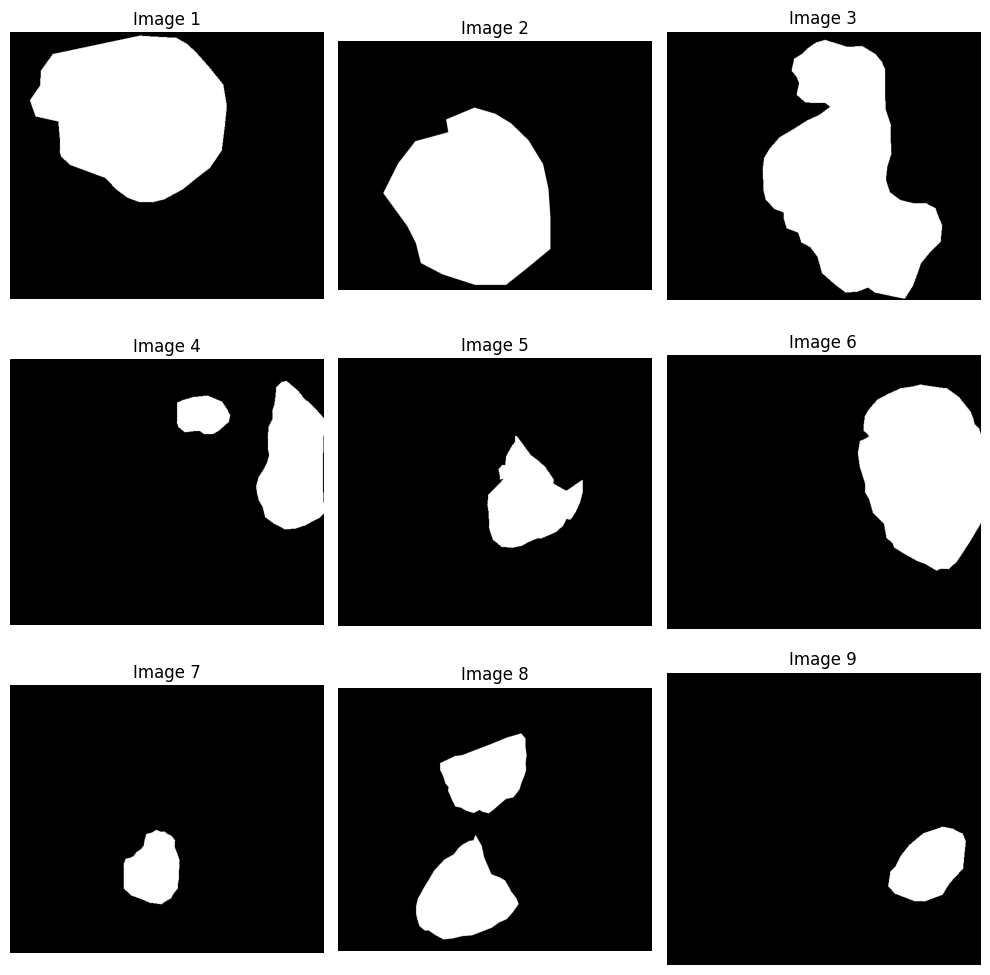

In [3]:
output_folder = "masks"
image_list = [img for img in os.listdir(output_folder) if img.endswith(".jpg")][:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))


for i, image_name in enumerate(image_list):

    image_path = os.path.join(output_folder, image_name)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    ax = axes[i // 3, i % 3]
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Image {i + 1}")


plt.tight_layout()
plt.show()

In [4]:
input_folder = 'images'
output_folder = 'out'

for image_name in os.listdir(input_folder):
    if image_name.endswith(".jpg"):
        image_path = os.path.join(input_folder, image_name)
        gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        gray_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
        gray_image = cv2.equalizeHist(gray_image)
        
        _, binary_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        output_path = os.path.join(output_folder, image_name)
        cv2.imwrite(output_path, binary_image)

print("Tumor segmentation completed for all images.")

Tumor segmentation completed for all images.


In [5]:
def mse(imageA, imageB):
    err = np.sum((imageA - imageB) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err

def compare_images(imageA, imageB):
    # Calculate MSE 
    m = mse(imageA, imageB)

    return m

def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
    return images

def compare_image_sets(folderA, folderB):
    imagesA = load_images_from_folder(folderA)
    imagesB = load_images_from_folder(folderB)

    if len(imagesA) != len(imagesB):
        raise ValueError("The folders do not contain the same number of images.")

    total_mse = 0


    for imgA, imgB in zip(imagesA, imagesB):
        m = compare_images(imgA, imgB)
        total_mse += m
 

    avg_mse = total_mse / len(imagesA)


    print(f"Average MSE: {avg_mse}")


folderA = 'out'
folderB = 'masks'
for mask in os.listdir(folderB):
    if mask.endswith(".jpg"):

        mask_path = os.path.join(folderB, mask)
        mask=cv2.imread(mask_path)
        mask_resize = cv2.resize(mask, (240,240))
        

compare_image_sets(folderA, folderB)


Average MSE: 0.8343285392807771


In [6]:
output_dir = 'out'
mask_dir = 'masks'

iou_values = []

for filename in os.listdir(output_dir):
    if filename.endswith(".jpg"):
        output_image_path = os.path.join(output_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        output_image = cv2.threshold(output_image, 0, 255, cv2.THRESH_BINARY)[1]
        mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)[1]
        intersection = cv2.bitwise_and(output_image, mask)
        union = cv2.bitwise_or(output_image, mask)
        iou = np.sum(intersection) / np.sum(union)
        iou_values.append(iou)

average_iou = np.mean(iou_values)
print(f"Average IoU: {average_iou:.4f}")


min_iou = np.min(iou_values)
print(f"Minimum IoU: {min_iou:.4f}")

max_iou = np.max(iou_values)
print(f"Maximum IoU: {max_iou:.4f}")

Average IoU: 0.2381
Minimum IoU: 0.0000
Maximum IoU: 0.8171


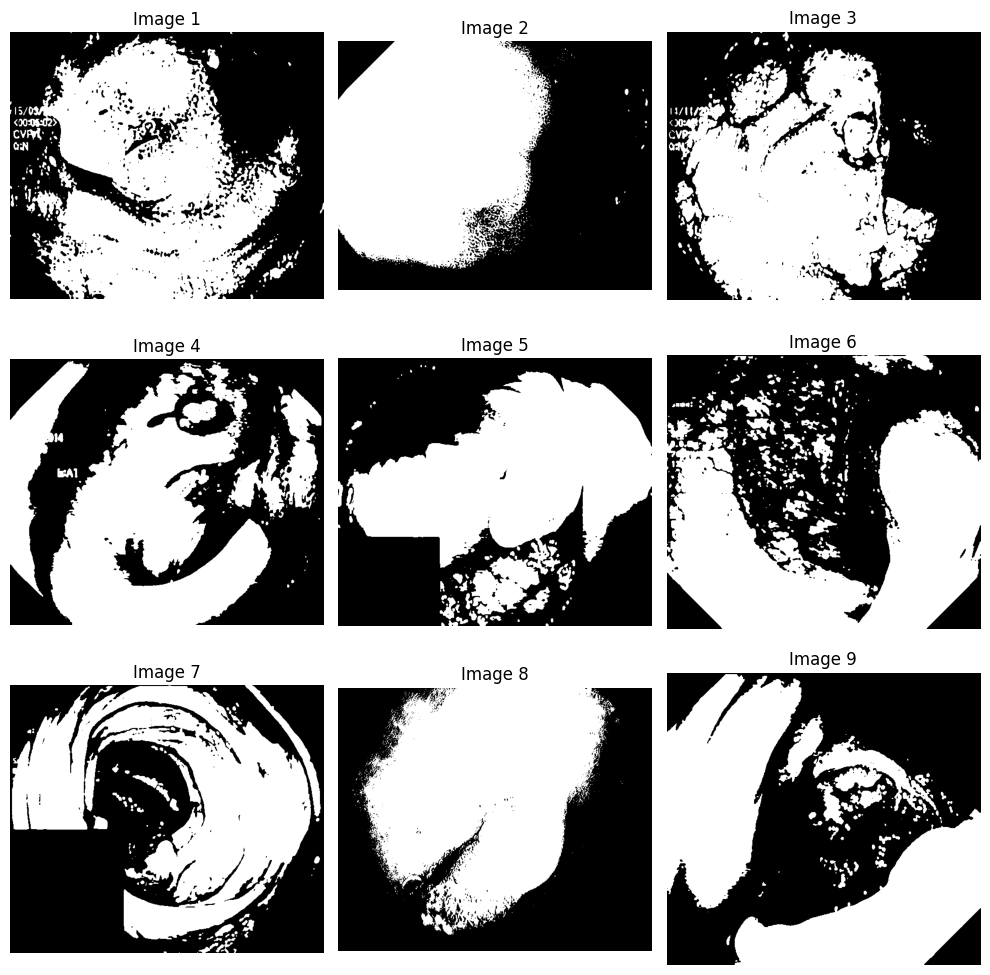

In [7]:
output_folder = "out"


image_list = [img for img in os.listdir(output_folder) if img.endswith(".jpg")][:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))


for i, image_name in enumerate(image_list):

    image_path = os.path.join(output_folder, image_name)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    ax = axes[i // 3, i % 3]
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Image {i + 1}")


plt.tight_layout()
plt.show()

normalizacija+morfoloske

In [8]:
def load_image(image_path):
    try:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            raise ValueError("Failed to read image")
        return image
    except Exception as e:
        print(f"Error loading image: {e}")
        return None

def preprocess_image(image):
    image = cv2.GaussianBlur(image, (5, 5), 0)
    image = cv2.equalizeHist(image)
    image = cv2.normalize(image, None, 0.0, 1.0, cv2.NORM_MINMAX)
    return image

def threshold_image(image):
    _, binary_image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary_image

def postprocess_image(binary_image):
    kernel = np.ones((3, 3), np.uint8)
    binary_image = cv2.erode(binary_image, kernel, iterations=2)
    binary_image = cv2.dilate(binary_image, kernel, iterations=2)
    return binary_image

def segment_tumor(image_path, output_path):
    image = load_image(image_path)
    if image is None:
        return

    image = preprocess_image(image)
    binary_image = threshold_image(image)
    binary_image = postprocess_image(binary_image)

    cv2.imwrite(output_path, binary_image)

input_folder = 'images'
output_folder = 'out'

for image_name in os.listdir(input_folder):
    if image_name.endswith(".jpg"):
        image_path = os.path.join(input_folder, image_name)
        output_path = os.path.join(output_folder, image_name)
        segment_tumor(image_path, output_path)

print("Tumor segmentation completed for all images.")

Tumor segmentation completed for all images.


In [9]:
def mse(imageA, imageB):

    err = np.sum((imageA - imageB) ** 2)
    err /= float(imageA.shape[0] * imageA.shape[1])
    return err

def compare_images(imageA, imageB):
    m = mse(imageA, imageB)

    return m

def load_images_from_folder(folder):
    images = []
    for filename in sorted(os.listdir(folder)):
        img = cv2.imread(os.path.join(folder, filename), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
    return images

def compare_image_sets(folderA, folderB):
    imagesA = load_images_from_folder(folderA)
    imagesB = load_images_from_folder(folderB)

    if len(imagesA) != len(imagesB):
        raise ValueError("The folders do not contain the same number of images.")

    total_mse = 0


    for imgA, imgB in zip(imagesA, imagesB):
        m = compare_images(imgA, imgB)
        total_mse += m
 

    avg_mse = total_mse / len(imagesA)


    print(f"Average MSE: {avg_mse}")


folderA = 'out'
folderB = 'masks'
for mask in os.listdir(folderB):
    if mask.endswith(".jpg"):
        mask_path = os.path.join(folderB, mask)
        mask=cv2.imread(mask_path)
        mask_resize = cv2.resize(mask, (240,240))
        

compare_image_sets(folderA, folderB)


Average MSE: 0.6968122387772726


In [10]:
output_dir = 'out'
mask_dir = 'masks'

iou_values = []

for filename in os.listdir(output_dir):
    if filename.endswith(".jpg"):
        output_image_path = os.path.join(output_dir, filename)
        mask_path = os.path.join(mask_dir, filename)
        output_image = cv2.imread(output_image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        output_image = cv2.threshold(output_image, 0, 255, cv2.THRESH_BINARY)[1]
        mask = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY)[1]
        intersection = cv2.bitwise_and(output_image, mask)
        union = cv2.bitwise_or(output_image, mask)
        iou = np.sum(intersection) / np.sum(union)
        iou_values.append(iou)

average_iou = np.mean(iou_values)
print(f"Average IoU: {average_iou:.4f}")


min_iou = np.min(iou_values)
print(f"Minimum IoU: {min_iou:.4f}")

max_iou = np.max(iou_values)
print(f"Maximum IoU: {max_iou:.4f}")

Average IoU: 0.2470
Minimum IoU: 0.0000
Maximum IoU: 0.8112


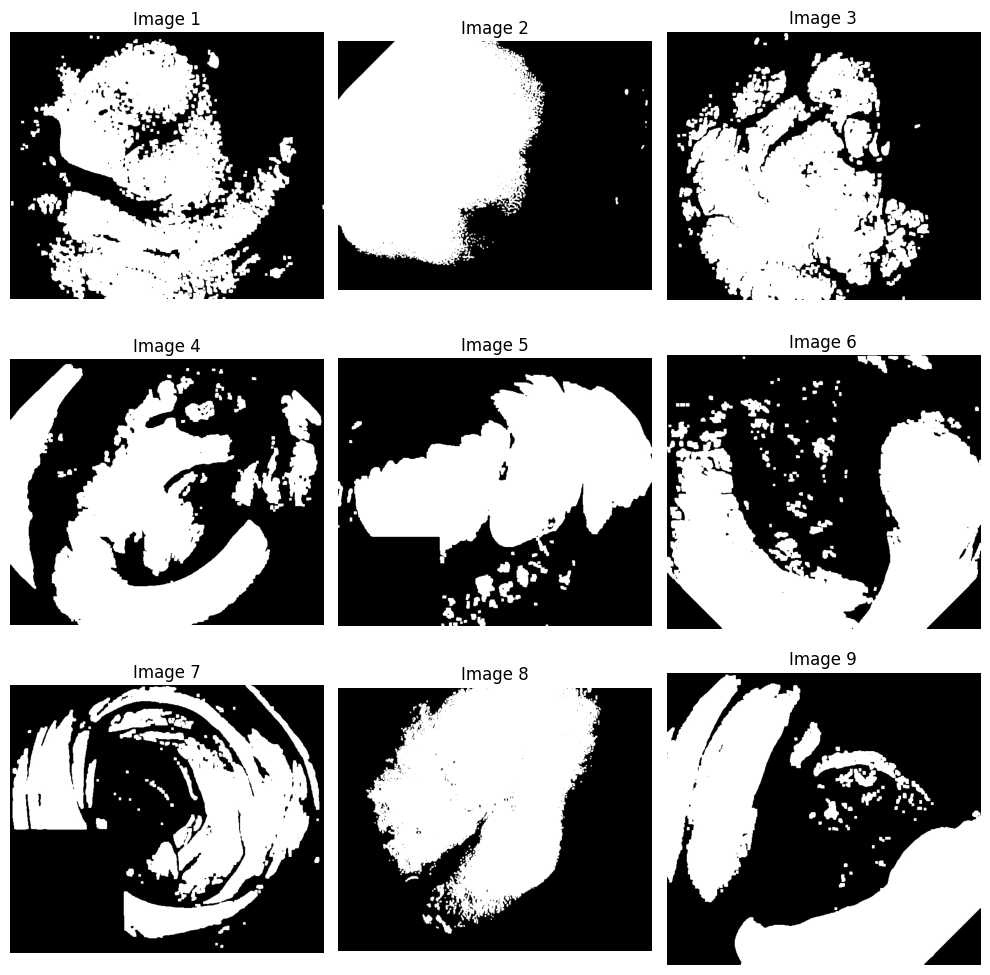

In [11]:
output_folder = "out"

image_list = [img for img in os.listdir(output_folder) if img.endswith(".jpg")][:9]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))


for i, image_name in enumerate(image_list):

    image_path = os.path.join(output_folder, image_name)
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    ax = axes[i // 3, i % 3]
    ax.imshow(image, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Image {i + 1}")


plt.tight_layout()
plt.show()